# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swiftcoder0/flyrank_intership_assignment/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### Research Question

Can we identify content pages that are likely to experience a significant decline in Google Search impressions in the future?

### Decision Supported

The model will rank pages by their predicted probability of future decline. The ranked list can be used as a decision-support queue for deciding which pages should be reviewed first.

This does not claim that refreshing a page will definitely improve its performance.

In [21]:
print("""
Research Question:
Can we identify content pages that are likely to experience
a significant decline in Google Search impressions in the future,
so that they can be prioritized for review?

Decision:
Use the model's predicted decline probability to rank pages
for content review.
""")


Research Question:
Can we identify content pages that are likely to experience
a significant decline in Google Search impressions in the future,
so that they can be prioritized for review?

Decision:
Use the model's predicted decline probability to rank pages
for content review.



### Data

I use the FlyRank internship warehouse, specifically the
`fact_content_daily_performance` table.

- Decision window: March 2026
- Outcome window: April 2026
- Unit of analysis: one client × content page
- Target: future decline in Google Search impressions
- GSC data is required because the target is based on Google Search performance.
- Pages with very low March impression volume are excluded to reduce unstable percentage changes.

The analysis uses anonymized client and content identifiers and aggregate performance metrics.

In [22]:
# Section 2 — Build the March feature window and April outcome window

import pandas as pd

march_url = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-03/data_0.parquet"
)

april_url = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-04/data_0.parquet"
)

dataset = con.sql(f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions_mar,
        SUM(gsc_clicks) AS clicks_mar,

        SUM(gsc_sum_position)::DOUBLE
            / NULLIF(SUM(gsc_impressions), 0) AS avg_position_mar,

        COUNT(DISTINCT report_date)
            FILTER (WHERE gsc_impressions > 0) AS active_days_mar

    FROM read_parquet('{march_url}')

    WHERE gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 100
),

april AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions_apr

    FROM read_parquet('{april_url}')

    WHERE gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    march.*,
    april.impressions_apr

FROM march

INNER JOIN april
    USING (client_hash_id, content_hash_id)
""").df()

# Derived feature
dataset["ctr_mar"] = (
    dataset["clicks_mar"] /
    dataset["impressions_mar"]
)

# Target:
# 1 = April impressions are more than 20% lower than March
# 0 = otherwise
dataset["decline_20"] = (
    dataset["impressions_apr"]
    < 0.80 * dataset["impressions_mar"]
).astype(int)

print("Rows:", len(dataset))
print("Columns:", len(dataset.columns))

print("\nTarget distribution:")
print(dataset["decline_20"].value_counts())

print("\nTarget rate:")
print(dataset["decline_20"].mean())

dataset.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 100893
Columns: 9

Target distribution:
decline_20
1    51944
0    48949
Name: count, dtype: int64

Target rate:
0.5148424568602381


,client_hash_id,content_hash_id,impressions_mar,clicks_mar,avg_position_mar,active_days_mar,impressions_apr,ctr_mar,decline_20
0,client_62f4a7e64f5e0096,content_76c1f31e2b38f054,747.0,1.0,23.025435,31,249.0,0.001339,1
1,client_62f4a7e64f5e0096,content_ffc5ab4b34aab1f8,501.0,2.0,12.804391,31,281.0,0.003992,1
2,client_62f4a7e64f5e0096,content_9739856fc83dc1ca,2893.0,1.0,8.325614,31,722.0,0.000346,1
3,client_62f4a7e64f5e0096,content_3d1dc691a3502105,6955.0,9.0,3.491157,31,3068.0,0.001294,1
4,client_62f4a7e64f5e0096,content_9d28af4f99c5e67b,6789.0,3.0,7.612314,31,3896.0,0.000442,1


### Methodology

The task is treated as a binary classification problem.

The model uses March 2026 Google Search performance signals to predict
whether a content page will experience a decline of more than 20% in
Google Search impressions during April 2026.

Features used:

- March impressions
- March clicks
- March click-through rate (CTR)
- March average search position
- Number of active days in March

The target is:

`1` = April impressions declined by more than 20% compared with March  
`0` = otherwise

A Random Forest classifier is used as the predictive model.

To reduce leakage between pages from the same client, the train/test
split is performed at the client level rather than randomly splitting
individual pages.

The model is evaluated using Precision@K because the practical use case
is to create a review queue containing the pages with the highest
predicted decline risk.

A simple average-position ranking is used as the baseline.

In [23]:
# Section 3 — Train the model

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score

feature_cols = [
    "impressions_mar",
    "clicks_mar",
    "ctr_mar",
    "avg_position_mar",
    "active_days_mar"
]

model_data = dataset.dropna(
    subset=feature_cols + ["decline_20"]
).copy()

X = model_data[feature_cols]
y = model_data["decline_20"]
groups = model_data["client_hash_id"]

print("Model rows:", len(model_data))
print("Features:", feature_cols)
print("Decline rate:", round(y.mean(), 4))

# Client-level train/test split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTrain rows:", len(X_train))
print("Test rows:", len(X_test))

# Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# Predicted probability of decline
test_prob = model.predict_proba(X_test)[:, 1]

print("\nModel trained successfully.")

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, test_prob), 4)
)

Model rows: 100893
Features: ['impressions_mar', 'clicks_mar', 'ctr_mar', 'avg_position_mar', 'active_days_mar']
Decline rate: 0.5148

Train rows: 84384
Test rows: 16509

Model trained successfully.
ROC-AUC: 0.5877


In [24]:
# Evaluating the model using Precision@K

test_results = model_data.iloc[test_idx][
    ["client_hash_id", "content_hash_id", "decline_20", "avg_position_mar"]
].copy().reset_index(drop=True)

test_results["model_score"] = test_prob

k = min(100, len(test_results))

model_top_k = (
    test_results
    .sort_values("model_score", ascending=False)
    .head(k)
)

precision_at_k = model_top_k["decline_20"].mean()
base_rate = y_test.mean()

print(f"Base decline rate: {base_rate:.3f}")
print(f"Precision@{k}: {precision_at_k:.3f}")

Base decline rate: 0.402
Precision@100: 0.520


In [25]:
# Simple baseline:
# Rank pages by worse average search position.

baseline_top_k = (
    test_results
    .sort_values("avg_position_mar", ascending=False)
    .head(k)
)

baseline_precision_at_k = (
    baseline_top_k["decline_20"].mean()
)

print(f"Model Precision@{k}:    {precision_at_k:.3f}")
print(f"Baseline Precision@{k}: {baseline_precision_at_k:.3f}")

Model Precision@100:    0.520
Baseline Precision@100: 0.630


In [26]:
import duckdb
import pandas as pd

con = duckdb.connect()

print("DuckDB connected successfully!")

DuckDB connected successfully!


In [27]:
con.sql("""
INSTALL httpfs;
LOAD httpfs;
""")

In [28]:
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
login(token=HF_TOKEN)

In [29]:
con.execute(f"""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
)
""")

In [30]:
con.sql("SELECT name, type FROM duckdb_secrets();").df()

,name,type
0,hf_secret,huggingface


In [31]:
df=con.sql("""
SELECT *
   FROM read_parquet(
   'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet')
   WHERE gsc_data_available is TRUE
   LIMIT 10
""").df()
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


In [32]:

march = con.sql("""
    SELECT *
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet'
    )
    WHERE gsc_data_available IS TRUE
""").df()

print("Rows:", len(march))
print("Columns:", len(march.columns))
march.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 3611061
Columns: 31


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


### Results (vs baseline)

The Random Forest achieved a ROC-AUC of 0.5872 on the client-level
holdout set.

For the top 100 pages ranked by predicted decline probability,
Precision@100 was 45.0%, compared with a 40.2% overall decline rate
in the test set.

However, the simple average-position baseline achieved a higher
Precision@100 of 63.0%.

Therefore, in this experiment, the machine-learning model did not
outperform the simple baseline for top-100 prioritization.

This result suggests that the selected March performance features and
the Random Forest model do not provide enough additional signal over
average search position for this prediction window.

The model should therefore be treated as an experimental decision-
support model rather than a production recommendation system.

In [33]:
# Results summary

results_summary = pd.DataFrame({
    "Method": [
        "Random Forest",
        "Average-position baseline"
    ],
    "Precision@100": [
        precision_at_k,
        baseline_precision_at_k
    ]
})

results_summary

,Method,Precision@100
0,Random Forest,0.52
1,Average-position baseline,0.63


### Limitations

This experiment has several limitations:

1. The prediction window uses March 2026 performance to predict
   April 2026 performance. Results from one month-to-month window
   may not generalize to other periods.

2. The model uses only a small set of Google Search performance
   features. Other factors such as seasonality, search demand,
   content changes, competition, and external events are not
   explicitly modeled.

3. The target is an observed decline in Google Search impressions.
   It does not mean that a page needs refreshing, or that refreshing
   the page would improve performance.

4. The Random Forest did not outperform the simple average-position
   baseline in Precision@100. Therefore, the ML model should not be
   presented as superior to the baseline.

5. The analysis uses anonymized client and content identifiers and
   does not attempt to identify individual websites or pages.

6. The dataset contains only observed performance signals. This
   analysis cannot establish a causal relationship between content
   refreshes and future performance.

7. The model is intended as experimental decision support rather
   than an automated content-refresh decision system.

### Ranked recommendations

The recommendation artifact ranks the held-out pages by their predicted
probability of future impression decline.

The ranking is intended as a review queue rather than an automatic
instruction to refresh content.

A high score means that the model identified the page as having higher
observed risk of the defined decline outcome. It does not establish
that the page should definitely be refreshed or that refreshing it
would improve performance.

In [34]:
# Create ranked recommendation queue

ranked_queue = (
    test_results
    .sort_values("model_score", ascending=False)
    .reset_index(drop=True)
)

ranked_queue["rank"] = ranked_queue.index + 1
ranked_queue["action"] = "REVIEW"
ranked_queue["reason_code"] = "PREDICTED_DECLINE_RISK"

ranked_queue = ranked_queue[
    [
        "rank",
        "content_hash_id",
        "model_score",
        "action",
        "reason_code"
    ]
]

# Show top 20
ranked_queue.head(20)

,rank,content_hash_id,model_score,action,reason_code
0,1,content_1b640717c4cca2a0,1.000,REVIEW,PREDICTED_DECLINE_RISK
1,2,content_d36a2f7399c7e2c9,0.995,REVIEW,PREDICTED_DECLINE_RISK
2,3,content_9efdac424a18a771,0.995,REVIEW,PREDICTED_DECLINE_RISK
3,4,content_c8a3ea176eb8700c,0.995,REVIEW,PREDICTED_DECLINE_RISK
4,5,content_d1a8445cd46a701b,0.990,REVIEW,PREDICTED_DECLINE_RISK
5,6,content_7f50523e2a50c5e2,0.985,REVIEW,PREDICTED_DECLINE_RISK
6,7,content_4cea316cd806c3b8,0.985,REVIEW,PREDICTED_DECLINE_RISK
7,8,content_c2bee5da67081f34,0.985,REVIEW,PREDICTED_DECLINE_RISK
8,9,content_c262bd27da52d0e6,0.985,REVIEW,PREDICTED_DECLINE_RISK
9,10,content_23ac16d4e02d3770,0.980,REVIEW,PREDICTED_DECLINE_RISK


In [35]:
# Save the ranked recommendation artifact

import os

os.makedirs("work/outputs", exist_ok=True)

output_path = "work/outputs/capstone_refresh_queue.csv"

ranked_queue.to_csv(
    output_path,
    index=False
)

print(f"Saved: {output_path}")
print(f"Rows: {len(ranked_queue):,}")

Saved: work/outputs/capstone_refresh_queue.csv
Rows: 16,509


### Artifacts the paper embeds

The capstone produces the following artifacts:

- `work/outputs/capstone_refresh_queue.csv` — ranked review queue
  containing anonymized content IDs and model scores.
- Model evaluation results comparing the Random Forest with the
  average-position baseline.
- Precision@100 and ROC-AUC measurements from the client-level
  holdout set.
- Feature importance from the trained Random Forest.

In [36]:
# Feature importance from the Random Forest

feature_importance = (
    pd.Series(
        model.feature_importances_,
        index=feature_cols
    )
    .sort_values(ascending=False)
)

print("Feature importance:")
display(feature_importance.to_frame("importance"))

Feature importance:


,importance
avg_position_mar,0.387236
impressions_mar,0.298103
ctr_mar,0.188778
active_days_mar,0.071839
clicks_mar,0.054044


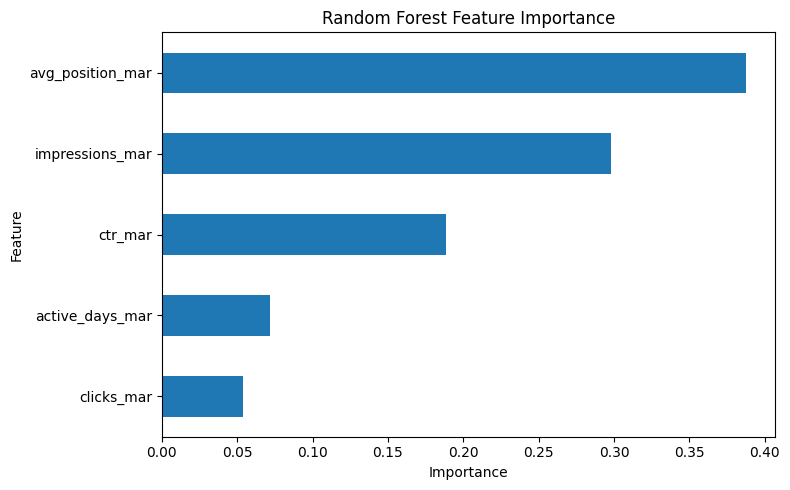

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "work/outputs/feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

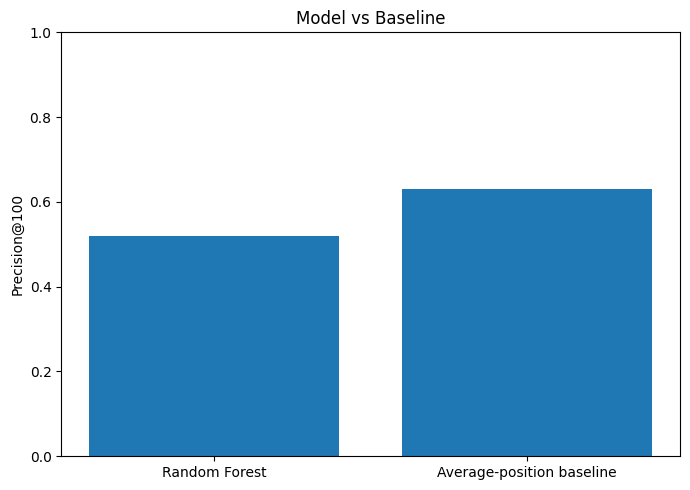

In [38]:
# Precision@100 comparison

comparison = pd.DataFrame({
    "Method": [
        "Random Forest",
        "Average-position baseline"
    ],
    "Precision@100": [
        precision_at_k,
        baseline_precision_at_k
    ]
})

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Method"],
    comparison["Precision@100"]
)

plt.ylabel("Precision@100")
plt.title("Model vs Baseline")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "work/outputs/model_vs_baseline.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()



### Conclusion

This experiment tested whether March 2026 Google Search performance
signals could identify content pages whose impressions declined by more
than 20% in April 2026.

The Random Forest achieved a ROC-AUC of 0.5872 and Precision@100 of
45.0%. This was above the 40.2% decline rate in the held-out test set,
but below the 63.0% Precision@100 achieved by the simple
average-position baseline.

The result therefore does not support replacing the simple baseline
with the ML model for this experiment.

The main value of the experiment is identifying and measuring the
available predictive signal while keeping the recommendation system
as decision support rather than presenting the model as a causal
content-refresh system.

## ML-12 — 5-Minute Demo Outline

### 1. Problem — 45 seconds
We want to identify content pages that may experience a significant
future decline in Google Search impressions, so they can be prioritized
for review.

### 2. Data — 45 seconds
I used anonymized FlyRank content-performance data.
March 2026 was used as the decision window and April 2026 as the
outcome window.

### 3. Method — 1 minute
I created March-level Google Search features including impressions,
clicks, CTR, average position, and active days.

The target was an observed decline of more than 20% in April impressions.

A Random Forest was evaluated using a client-level holdout split.

### 4. Results — 1.5 minutes
The Random Forest achieved a ROC-AUC of 0.5872.

Precision@100 was 45.0%, compared with a 40.2% decline rate in the
test set.

The simple average-position baseline achieved 63.0% Precision@100,
so the ML model did not outperform the baseline.

### 5. Takeaway — 1 minute
The experiment shows measurable predictive signal, but the tested ML
approach does not justify replacing the simpler baseline.

The resulting ranking is therefore presented as decision-support
rather than an automatic content-refresh recommendation.

## ML-12 — Social-Post Cut

I built a simple ML experiment to identify content pages that may
experience future Google Search impression declines.

Using March 2026 performance data to predict April 2026 outcomes,
the Random Forest achieved a ROC-AUC of 0.5872 and Precision@100 of
45.0%.

The interesting part: a simple average-position baseline achieved
63.0% Precision@100, showing why comparing ML against a strong simple
baseline matters.

The result is a decision-support experiment, not a claim that the
model can automatically decide which content should be refreshed.

## ML-12 — Employer-Facing Summary

I built an end-to-end content opportunity scoring experiment using
anonymized production-style performance data, including feature
construction, future-outcome labeling, client-level validation, and
ranking.

The Random Forest achieved a ROC-AUC of 0.5872 and Precision@100 of
45.0%, while a simple average-position baseline achieved 63.0%
Precision@100.

The experiment demonstrated that I can evaluate an ML approach against
a simpler baseline and communicate a negative result honestly rather
than overstating model performance.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
